ECG image Classification Using CNN 

In [1]:
import os

In [5]:
dataset_path = 'C:\\Users\\91954\\Downloads\\ECG_dataset'

In [7]:
abnormal_heatbeat_image=len(os.listdir(os.path.join(dataset_path,"Abnormal_Heartbeat")))
covid_19_image=len(os.listdir(os.path.join(dataset_path,"Covid_19")))
mi_image=len(os.listdir(os.path.join(dataset_path,"MI")))
mi_history_image=len(os.listdir(os.path.join(dataset_path,"MI_History")))
normal_image=len(os.listdir(os.path.join(dataset_path,"Normal")))

In [9]:
print("Normal :",normal_image)
print("covid_19:",covid_19_image)
print("mi:",mi_image)
print("mi_history:",mi_history_image)
print("abnormal_heartbeat :",abnormal_heatbeat_image)

Normal : 859
covid_19: 250
mi: 74
mi_history: 203
abnormal_heartbeat : 546


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
labels=["Abnormal Heartbeat","Covid_19","MI","Past MI History","Normal"]
counts=[abnormal_heatbeat_image,covid_19_image,mi_image,mi_history_image,normal_image]

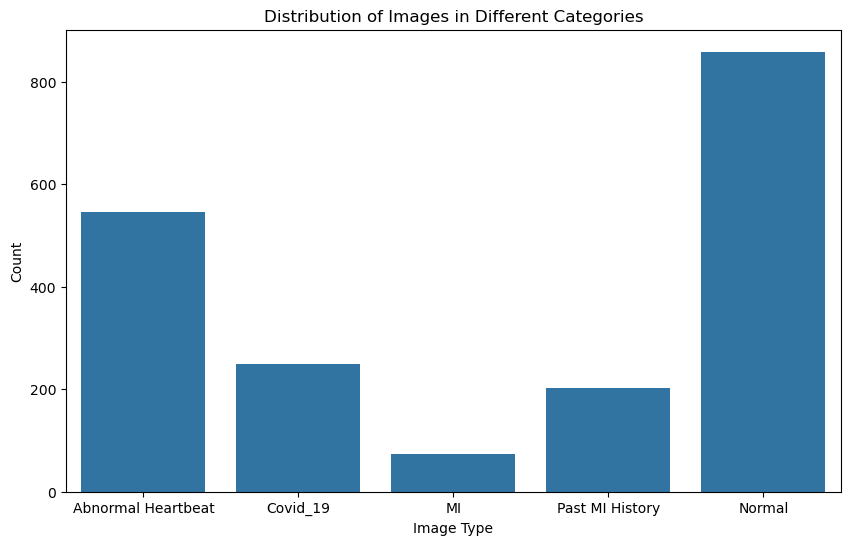

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=counts)
plt.xlabel('Image Type')
plt.ylabel('Count')
plt.title('Distribution of Images in Different Categories')
plt.show()

In [15]:
abnormal_heartbeat_path = os.path.join(dataset_path, "Abnormal_Heartbeat")
covid_19_path = os.path.join(dataset_path, "Covid_19")
mi_path = os.path.join(dataset_path, "MI")
mi_history_path = os.path.join(dataset_path, "MI_History")
normal_path = os.path.join(dataset_path, "Normal")

In [17]:
import cv2

In [19]:
covid_19_files = os.listdir(covid_19_path)
normal_files = os.listdir(normal_path)
mi_files = os.listdir(mi_path)
prev_mi_files = os.listdir(mi_history_path)
abnormal_heartbeat_files = os.listdir(abnormal_heartbeat_path)

In [21]:
#View Images
def view_image(image_name,image_files,image_file_path):
    fig,axes=plt.subplots(3,3,figsize=(10,10))
    fig.suptitle(image_name,fontsize=16)
    axes=axes.ravel()
    
    for i,image_file in enumerate(image_files[:9]):
        image_path=os.path.join(image_file_path,image_file)
        image=cv2.imread(image_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

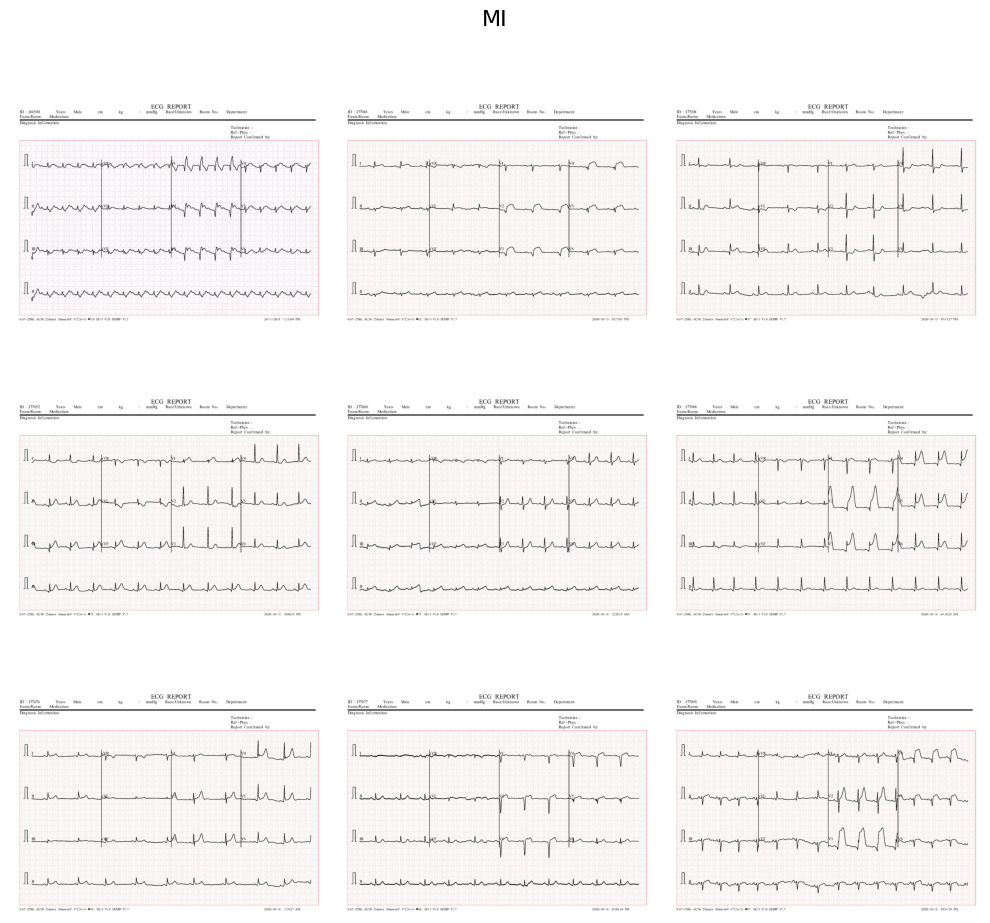

In [18]:
view_image("MI",mi_files,mi_path)

# Preprocessing and loading images

In [23]:
# Since it's image data, hence we have to ensure all images have same pixel size 
# so resizing the image by 128*128
def load_and_preprocess_image(image_folder):
    image_files = os.listdir(image_folder)
    images = []
    
    for image_file in image_files :
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            image = cv2.resize(image, (128,128))
            images.append(image)
    return images


In [25]:
abnormal_heartbeat_files = load_and_preprocess_image(abnormal_heartbeat_path)
covid_19_files = load_and_preprocess_image(covid_19_path)
mi_files = load_and_preprocess_image(mi_path)
mi_history_files = load_and_preprocess_image(mi_history_path)
normal_files = load_and_preprocess_image(normal_path)

In [27]:
import numpy as np

In [29]:
#Reshaping the pixel matrix into a 4-D shape  where the first dimension accommodates the variable number of images, 
# and the other dimensions are fixed at 128x128 pixels with 3 color channels.

abnormal_heartbeat_files = np.array(abnormal_heartbeat_files).reshape(-1, 128, 128, 3)
covid_19_files = np.array(covid_19_files).reshape(-1, 128, 128, 3)
mi_files = np.array(mi_files).reshape(-1, 128, 128, 3)
mi_history_files = np.array(mi_history_files).reshape(-1, 128, 128, 3)
normal_files = np.array(normal_files).reshape(-1, 128, 128, 3)

In [31]:
all_files = np.concatenate((abnormal_heartbeat_files, covid_19_files, mi_files,mi_history_files,
                           normal_files), axis=0)

all_labels = np.concatenate((
np.zeros(len(abnormal_heartbeat_files)),
np.ones(len(covid_19_files)),
np.ones(len(mi_files)) * 2,
    np.ones(len(mi_history_files)) * 3,
    np.ones(len(normal_files))*4
))

In [33]:
#converting 4D array into 2-D array using ndarray.reshape(-1,Height,Width,Color Channels)
all_files_flaten=all_files.reshape(-1,all_files.shape[1]*all_files.shape[2]*all_files.shape[3]) 

In [35]:
import numpy as np
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
all_files_flat_resampled, all_labels_resampled = ros.fit_resample(all_files_flaten, all_labels)

In [37]:
unique_resampled, counts_resampled = np.unique(all_labels_resampled, return_counts=True)

class_counts_resampled = dict(zip(unique_resampled, counts_resampled))

print("New class distribution after resampling:", class_counts_resampled)

New class distribution after resampling: {0.0: 859, 1.0: 859, 2.0: 859, 3.0: 859, 4.0: 859}


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [41]:
X_train, X_test, y_train, y_test = train_test_split(all_files_flat_resampled, all_labels_resampled, test_size=0.2, stratify=all_labels_resampled,
                                                    random_state=42)

# Scaling the pixel values

In [43]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

In [45]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [49]:
X_train_scaled.shape

(3436, 49152)

In [51]:
y_train.shape

(3436,)

In [53]:
model = Sequential()

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))  # Increased dropout due to overfitting

# Flattening the output
model.add(Flatten())

# Fully Connected (Dense) Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(5, activation='softmax'))


In [59]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(optimizer=Adam(learning_rate=0.001),
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])


In [61]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,181 (12.61 MB)

 Trainable params: 3,305,733 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [63]:
from sklearn.utils import class_weight

In [65]:
X_train_scaled_new = X_train_scaled.reshape(-1, 128, 128, 3)

In [71]:
history = model.fit(
    X_train_scaled_new, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.4444 - loss: 1.0722 - val_accuracy: 0.1991 - val_loss: 77.4232
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5223 - loss: 0.9184 - val_accuracy: 0.2006 - val_loss: 42.0711
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5450 - loss: 0.8911 - val_accuracy: 0.3430 - val_loss: 5.5515
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5915 - loss: 0.8688 - val_accuracy: 0.3372 - val_loss: 13.3576
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6249 - loss: 0.8186 - val_accuracy: 0.2951 - val_loss: 21.2644
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6158 - loss: 0.8066 - val_accuracy: 0.3852 - val_loss: 13.7294
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6277 - loss: 0.8150 - val_accuracy: 0.5451 - val_loss: 1.2057
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6579 - loss: 0.7334 - val_accuracy: 0.5320 - va

## Saving the model

In [78]:
model.save(r'C:\Users\91954\Downloads\ECG_dataset.keras')

In [155]:
from keras.models import load_model

model = load_model(r'C:\Users\91954\Downloads\ECG_dataset.keras')


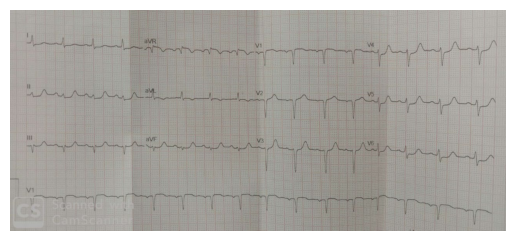

In [157]:
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

# Loading the test image
img_path = r'C:\Users\91954\Downloads\ECG_dataset\testing\ecg.jpeg'
import matplotlib.image as mpimg

img = mpimg.imread(img_path)

# Display the image
plt.imshow(img)
plt.axis('off')  
plt.show()

In [159]:
img = image.load_img(img_path, target_size=(128, 128))  
img_array= np.array(img).reshape(-1, 128, 128, 3)

In [161]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step


In [163]:
predicted_class_index = np.argmax(predictions)
confidence = predictions[0, predicted_class_index]

print("Predicted class index:", predicted_class_index)
print("Confidence:", confidence)


Predicted class index: 3
Confidence: 1.0


In [167]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

In [169]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image with Keras preprocessing
img = image.load_img(img_path, target_size=(128, 128))

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Add an extra dimension for batch size, making it (1, height, width, channels)
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (if necessary)
img_array = img_array / 255.0  # Optional depending on your model's input requirements

# Ensure it is a tensor (this might not be necessary if you're already working with TensorFlow tensors)
img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


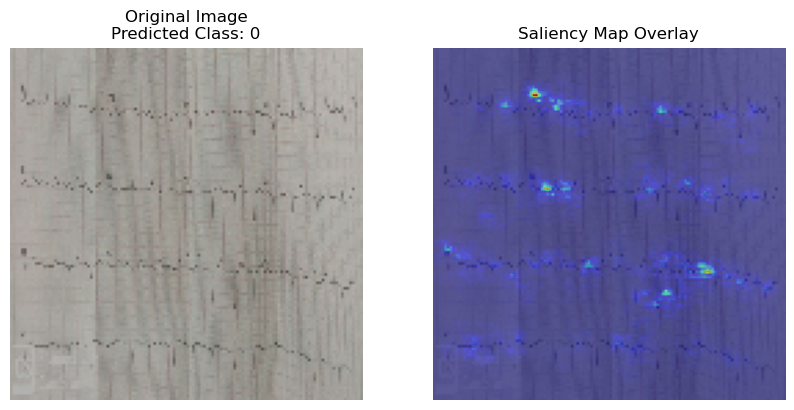

In [177]:
# Define a function to calculate the saliency map
def compute_saliency_map(model, img_array, class_idx):
    # Set up the gradient tape for automatic differentiation
    with tf.GradientTape() as tape:
        tape.watch(img_array)  # Watch the input image for gradients
        # Make a prediction
        prediction = model(img_array)
        # Get the class probability for the target class
        class_output = prediction[:, class_idx]
    
    # Compute the gradients of the class output with respect to the input image
    gradients = tape.gradient(class_output, img_array)
    
    # Compute the absolute value of the gradients to get saliency
    saliency_map = tf.reduce_max(tf.abs(gradients), axis=-1)
    
    return saliency_map

# Get the predicted class index (assuming it's a classification problem)
predicted_class = np.argmax(model.predict(img_array), axis=-1)
class_idx = predicted_class[0]  # The class index of the predicted class

# Compute the saliency map
saliency_map = compute_saliency_map(model, img_array, class_idx)

# Normalize the saliency map to the range [0, 1]
saliency_map = saliency_map[0].numpy()
saliency_map = np.maximum(saliency_map, 0)  # Remove negative values
saliency_map = saliency_map / saliency_map.max()  # Normalize to [0, 1]

# Visualize the image and overlay the saliency map
plt.figure(figsize=(10, 10))

# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(img_array[0])
plt.title(f"Original Image\nPredicted Class: {class_idx}")
plt.axis('off')

# Display the saliency map overlayed on the image
plt.subplot(1, 2, 2)
plt.imshow(img_array[0])
plt.imshow(saliency_map, cmap='jet', alpha=0.5)  # Overlay heatmap with alpha blending
plt.title(f"Saliency Map Overlay")
plt.axis('off')

plt.show()

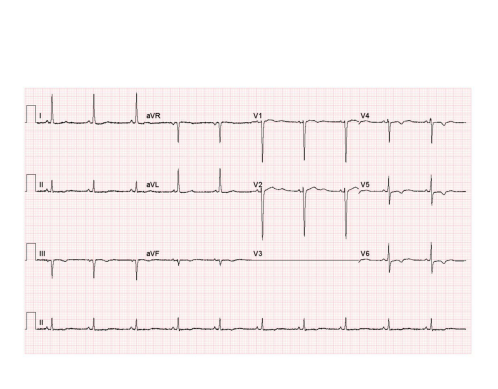

In [181]:
img_path=r"C:\Users\91954\Downloads\ECG_dataset\Covid_19\Binder1_Page_097.jpg"

img = mpimg.imread(img_path)

# Display the image
plt.imshow(img)
plt.axis('off')  
plt.show()

In [183]:
img = image.load_img(img_path, target_size=(128, 128))  
img_array= np.array(img).reshape(-1, 128, 128, 3)

In [185]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


In [187]:
predicted_class_index = np.argmax(predictions)
confidence = predictions[0, predicted_class_index]

print("Predicted class index:", predicted_class_index)
print("Confidence:", confidence)


Predicted class index: 1
Confidence: 1.0


In [189]:

# Load the image with Keras preprocessing
img = image.load_img(img_path, target_size=(128, 128))

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Add an extra dimension for batch size, making it (1, height, width, channels)
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (if necessary)
img_array = img_array / 255.0  # Optional depending on your model's input requirements

# Ensure it is a tensor (this might not be necessary if you're already working with TensorFlow tensors)
img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


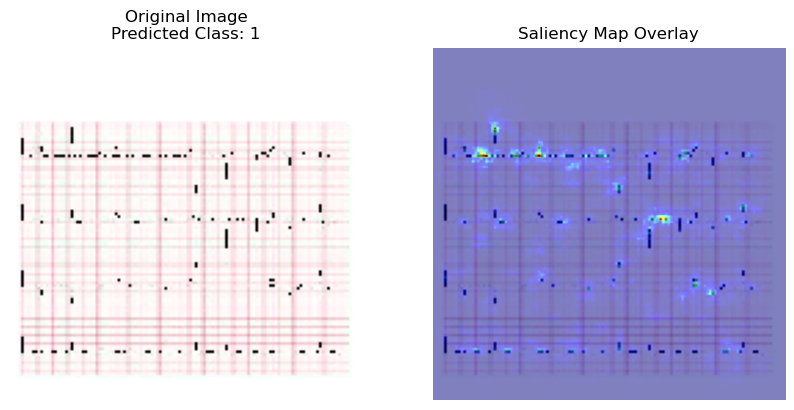

In [191]:
# Define a function to calculate the saliency map
def compute_saliency_map(model, img_array, class_idx):
    # Set up the gradient tape for automatic differentiation
    with tf.GradientTape() as tape:
        tape.watch(img_array)  # Watch the input image for gradients
        # Make a prediction
        prediction = model(img_array)
        # Get the class probability for the target class
        class_output = prediction[:, class_idx]
    
    # Compute the gradients of the class output with respect to the input image
    gradients = tape.gradient(class_output, img_array)
    
    # Compute the absolute value of the gradients to get saliency
    saliency_map = tf.reduce_max(tf.abs(gradients), axis=-1)
    
    return saliency_map

# Get the predicted class index (assuming it's a classification problem)
predicted_class = np.argmax(model.predict(img_array), axis=-1)
class_idx = predicted_class[0]  # The class index of the predicted class

# Compute the saliency map
saliency_map = compute_saliency_map(model, img_array, class_idx)

# Normalize the saliency map to the range [0, 1]
saliency_map = saliency_map[0].numpy()
saliency_map = np.maximum(saliency_map, 0)  # Remove negative values
saliency_map = saliency_map / saliency_map.max()  # Normalize to [0, 1]

# Visualize the image and overlay the saliency map
plt.figure(figsize=(10, 10))

# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(img_array[0])
plt.title(f"Original Image\nPredicted Class: {class_idx}")
plt.axis('off')

# Display the saliency map overlayed on the image
plt.subplot(1, 2, 2)
plt.imshow(img_array[0])
plt.imshow(saliency_map, cmap='jet', alpha=0.5)  # Overlay heatmap with alpha blending
plt.title(f"Saliency Map Overlay")
plt.axis('off')

plt.show()